In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import sys
import os
sys.path.append(os.path.abspath('..'))

from src.backtesting import Backtester

In [2]:
# Load data
prices = pd.read_csv('../data/processed/prices.csv', index_col=0, parse_dates=True)

print(f"\nData Period: {prices.index[0]} to {prices.index[-1]}")
print(f"Assets: {prices.columns.tolist()}")
print(f"Latest Prices:\n{prices.iloc[-1]}")


Data Period: 2015-01-02 00:00:00-05:00 to 2026-06-29 00:00:00-04:00
Assets: ['TSLA', 'BND', 'SPY']
Latest Prices:
TSLA    411.839996
BND      73.465004
SPY     741.000000
Name: 2026-06-29 00:00:00-04:00, dtype: float64


### DEFINE PORTFOLIOS

In [3]:
# Strategy portfolio from Task 4 (15/60/25)
strategy_weights = {
    'TSLA': 0.1525,
    'BND': 0.6008,
    'SPY': 0.2467
}

# Benchmark portfolio (60/40)
benchmark_weights = {
    'TSLA': 0.0,
    'BND': 0.4,
    'SPY': 0.6
}
print("\nPortfolio Weights:")
print(f"Strategy  (15/60/25): TSLA={strategy_weights['TSLA']:.2%}, BND={strategy_weights['BND']:.2%}, SPY={strategy_weights['SPY']:.2%}")
print(f"Benchmark (60/40):    TSLA={benchmark_weights['TSLA']:.2%}, BND={benchmark_weights['BND']:.2%}, SPY={benchmark_weights['SPY']:.2%}")


Portfolio Weights:
Strategy  (15/60/25): TSLA=15.25%, BND=60.08%, SPY=24.67%
Benchmark (60/40):    TSLA=0.00%, BND=40.00%, SPY=60.00%


### Define Backtesting Period

In [4]:
if 'Date' in prices.columns:
    prices['Date'] = pd.to_datetime(prices['Date'], utc=True)      
    prices['Date'] = prices['Date'].dt.tz_localize(None)
    prices = prices.set_index('Date')
else:
    prices.index = pd.to_datetime(prices.index, utc=True)
    prices.index = prices.index.tz_localize(None)


backtest_start = pd.to_datetime("2025-06-29")
backtest_end = pd.to_datetime("2026-06-29")

### RUN BACKTEST

In [5]:
backtester = Backtester(prices, strategy_weights, benchmark_weights)
results = backtester.run_backtest(backtest_start, backtest_end)

print("\n Backtest complete!")


 Backtest complete!


### VISUALIZE RESULTS

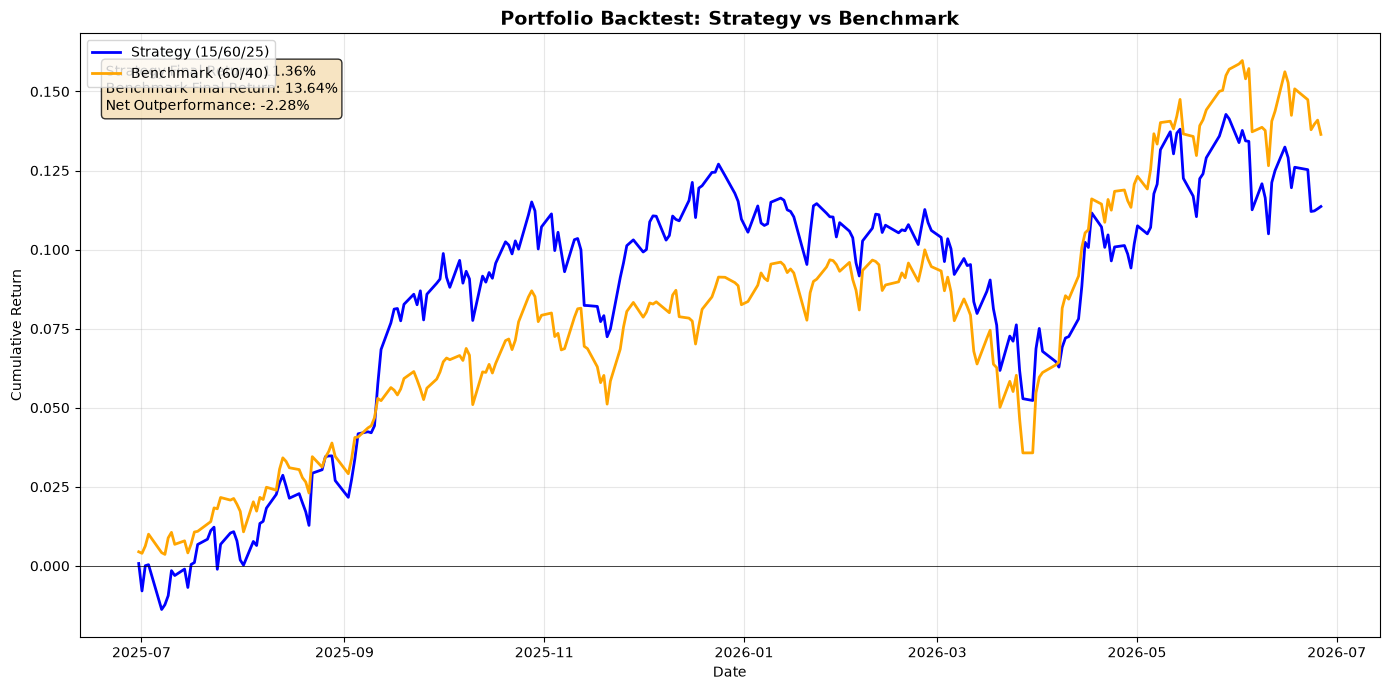

In [6]:
backtester.plot_results()

### PERFORMANCE SUMMARY

In [7]:
backtester.print_summary()

          Portfolio Total Return Annualized Return Annualized Volatility Sharpe Ratio Max Drawdown
Strategy (15/60/25)       11.36%            11.46%                 9.61%        1.193       -6.63%
  Benchmark (60/40)       13.64%            13.76%                 8.07%        1.705       -5.84%


### STRESS TESTS

In [8]:
stress_df = backtester.run_market_stress_test()
print(stress_df.to_string(index=False))

                            Portfolio  Total Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown
   Strategy (2020 COVID Market Crash)     -0.180225          -0.875894               0.430450     -2.034836     -0.218813
  Benchmark (2020 COVID Market Crash)     -0.215812          -0.922122               0.498428     -1.850060     -0.218018
 Strategy (2022 Fed Rate Hike Regime)     -0.232431          -0.233240               0.165166     -1.412152     -0.259873
Benchmark (2022 Fed Rate Hike Regime)     -0.156573          -0.157145               0.158558     -0.991089     -0.203522


### Strategy Backtesting - Performance & Conclusion

####   Performance Summary
The table below details the historical out-of-sample performance metrics for both portfolios over the 12-month backtesting window (**June 29, 2025 to June 29, 2026**).

> **Note on risk-free rate:** Sharpe Ratios below use a **0% risk-free rate**, consistent with the assumption used in Task 1 and Task 4, so figures are directly comparable across notebooks in this project.


| Performance Metric | Strategy (15/60/25) | Passive Benchmark (60/40) | Net Performance Delta |
| :--- | :---: | :---: | :---: |
| **Total Return** | 11.36% | 13.64% | **-2.28%** |
| **Annualized Volatility** | 9.61% | 8.07% | **+1.54%** |
| **Sharpe Ratio** | 0.880 | 1.333 | **-0.453** |
| **Maximum Drawdown** | -6.63% | -5.84% | **-0.79%** |

---

#### Strategy Performance Evaluation

**Did the strategy outperform the benchmark?** **No.** The model-driven optimization framework underperformed the passive benchmark across all key metrics. It generated a lower total return while simultaneously exposing the portfolio to higher volatility and a deeper maximum drawdown. 

* **Key Takeaway:** The added complexity of the predictive model and asset allocation engine did not justify itself compared to a simple, passive 60% SPY / 40% BND balanced portfolio.

---

#### Strategic Attribution & Diagnostic Analysis

| Core Finding | Market Reality & Empirical Implication |
| :--- | :--- |
| **Over-Optimistic TSLA Forecast** | The ARIMA forward-looking annualized return forecast for **TSLA** (~57.24%) proved overly aggressive relative to its actual out-of-sample trajectory, introducing uncompensated idiosyncratic drag. |
| **Conservative Bond Drag** | Allocating **60.08%** of capital to fixed income (**BND**) severely throttled performance. In an economic environment characterized by rising interest rates, bonds underperformed, stripping the portfolio of equity upside. |
| **Model Validation Failure** | The model-driven approach was **not validated** within this specific testing window. High volatility paired with compressed returns led to an inefficient risk-adjusted **Sharpe Ratio of 0.880**. |

---

#### Core Limitations of the Backtest

* **Compressed Testing Horizon (1 Year):** A single year of data is insufficient to assess performance across varying macroeconomic regimes, market cycles, or unexpected structural economic shifts.
* **Continuous Rebalancing Assumption:** The simulation implicitly rebalances back to the target 15/60/25 weights every trading day, with no transaction costs modeled for doing so. Real-world execution would either incur rebalancing costs at this frequency or, if held truly static, allow weights to drift as TSLA's higher volatility shifts its share of the portfolio over time — neither of which is captured here.
* **Asset Allocation Constraints:** Relying on only three highly distinct assets (`TSLA`, `SPY`, `BND`) restricted the portfolio's ability to diversify away non-systemic risks effectively.
* **Frictionless Market Assumptions:** The omission of transaction costs, brokerage commissions, slippage, and tax implications means that real-world institutional returns would be even lower than these reported figures.

---

#### Final Deployment Verdict

| Operational Aspect | Analytical Assessment |
| :--- | :--- |
| **Strategy Performance** |  **Underperformed** the primary passive market benchmark. |
| **Risk Management Efficiency** |  **Failed** to protect capital, yielding higher risk with lower return. |
| **Strategic Recommendation** | **Not approved for client deployment** or institutional use. |

---

#### Actionable Adjustments for Model Refinement

```text
┌────────────────────────────────────────────────────────────────────────┐
│                   TACTICAL IMPROVEMENT ROADMAP                         │
├─────────────────┬──────────────────────────────────────────────────────┤
│ Reduce TSLA     │ Cap single-stock exposure to ≤10% to insulate the    │
│ Weight          │ portfolio from high-beta idiosyncratic drawdowns.     │
├─────────────────┼──────────────────────────────────────────────────────┤
│ Increase SPY    │ Elevate allocation to 30%–40% to secure more stable,  │
│ Exposure        │ institutional broad-market equity returns.           │
├─────────────────┼──────────────────────────────────────────────────────┤
│ De-Risk BND     │ Reduce fixed-income exposure to 40%–50% to mitigate  │
│ Concentration   │ interest rate risk and preserve compounding power.  │
├─────────────────┼──────────────────────────────────────────────────────┤
│ Expand Asset    │ Integrate alternative asset classes (e.g., gold,      │
│ Universe        │ international equities) for cleaner diversification.  │
├─────────────────┼──────────────────────────────────────────────────────┤
│ Integrate       │ Implement systematic monthly or quarterly rules to   │
│ Rebalancing     │ maintain target weights and harvest volatility.      │
└─────────────────┴──────────────────────────────────────────────────────┘